<a href="https://colab.research.google.com/github/temitope2021/Data_Science-Artificial_Intelligence_Machine_Learning/blob/main/!Deep_learning_with_Tensorflow_fishdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
batch_size = 32
img_height = 180
img_width = 180
epochs = 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gdown

In [ ]:
import gdown

# Your file ID from the shared link
file_id = "1kYENL9KHZeIi1x6YDGvNNYXV7jV3Ffxg"
url = f"https://drive.google.com/uc?id={file_id}"


output = "Fish dataset(Assignment).zip"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1kYENL9KHZeIi1x6YDGvNNYXV7jV3Ffxg
From (redirected): https://drive.google.com/uc?id=1kYENL9KHZeIi1x6YDGvNNYXV7jV3Ffxg&confirm=t&uuid=acb239df-ae14-492b-a01b-88d2f0a9560a
To: /content/Fish dataset(Assignment).zip
100%|██████████| 1.70G/1.70G [00:16<00:00, 105MB/s]


'Fish dataset(Assignment).zip'

In [ ]:
#  Unzip the dataset
import zipfile
import os

with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall("/content/fish_dataset/FishImgDataset/")

os.listdir("//content/fish_dataset/FishImgDataset")

# then save the dataset in a varable for your reference
fish_datapath = "//content/fish_dataset/FishImgDataset"

In [ ]:
import tensorflow as tf

#point to the parent folder that contains subfolders (e.g. /train/boat)
 #Your dataset paths
train_dir = "/content/fish_dataset/FishImgDataset/FishImgDataset/train/"
test_dir = "/content/fish_dataset/FishImgDataset/FishImgDataset/test/"
val_dir = "/content/fish_dataset/FishImgDataset/FishImgDataset/val/"

# Load the image datasets
train_data = tf.keras.utils.image_dataset_from_directory(
   train_dir,
   image_size=(224, 224),
   batch_size=32
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32
)

class_names = test_data.class_names

Found 8809 files belonging to 31 classes.
Found 1761 files belonging to 31 classes.
Found 2751 files belonging to 31 classes.


**Visualize the training dataset**

Classes: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb', 'Silver Carp', 'Silver Perch', 'Snakehead', 'Tenpounder', 'Tilapia']


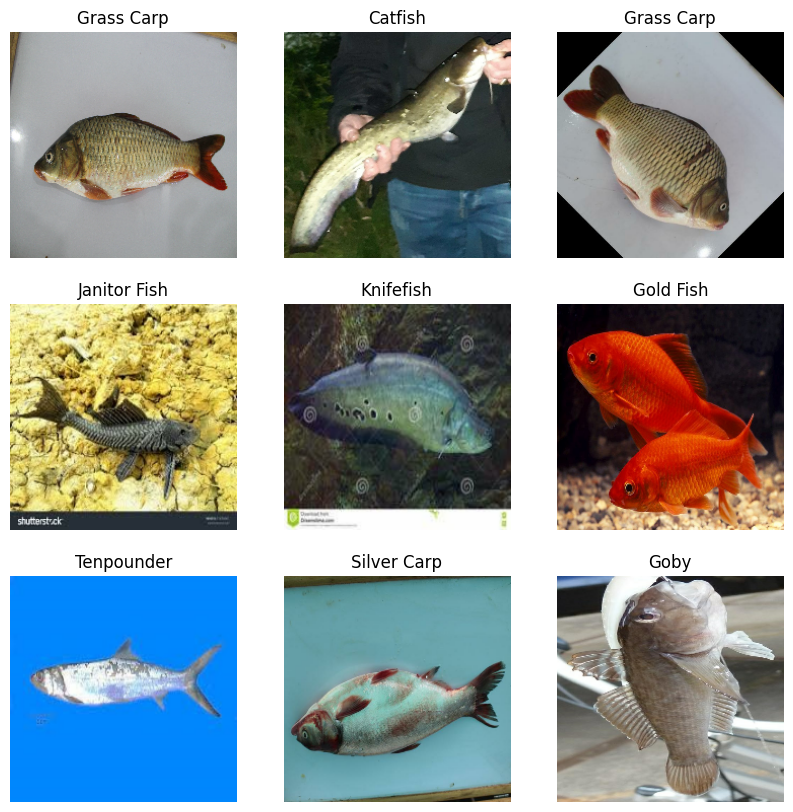

In [ ]:
import matplotlib.pyplot as plt

# Check the class names
class_names = train_data.class_names
print("Classes:", class_names)

# Visualize 9 sample images from the training data
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

**Shuffle and optimize the set before training**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

Build The First CNN Model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,172,959 (42.62 MB)

 Trainable params: 11,172,959 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1183s 4s/step - accuracy: 0.1494 - loss: 3.2782 - val_accuracy: 0.3232 - val_loss: 2.4019
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1177s 4s/step - accuracy: 0.3239 - loss: 2.4412 - val_accuracy: 0.4944 - val_loss: 1.7946
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1171s 4s/step - accuracy: 0.4493 - loss: 1.9154 - val_accuracy: 0.6710 - val_loss: 1.2265
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1145s 4s/step - accuracy: 0.5642 - loss: 1.4871 - val_accuracy: 0.7855 - val_loss: 0.8843
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1142s 4s/step - accuracy: 0.6567 - loss: 1.1005 - val_accuracy: 0.8590 - val_loss: 0.6359
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1174s 4s/step - accuracy: 0.7437 - loss: 0.8360 - val_accuracy: 0.8902 - val_loss: 0.4822
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1136s 4s/step - accuracy: 0.7732 - loss: 0.6946 - val_accuracy: 0.9189 - val_loss: 0.4040
Epoch 8/10
230/276 ━━━━━━━━━━━━━━━━━━━━ 2:54 4s/step - accuracy: 0.8168 - loss: 0.5689

Test_set Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.3f} ")

56/56 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9030 - loss: 0.5746
Test Accuracy: 0.892 


Predicting And Visualizing The First 9 Predicted Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 958ms/step


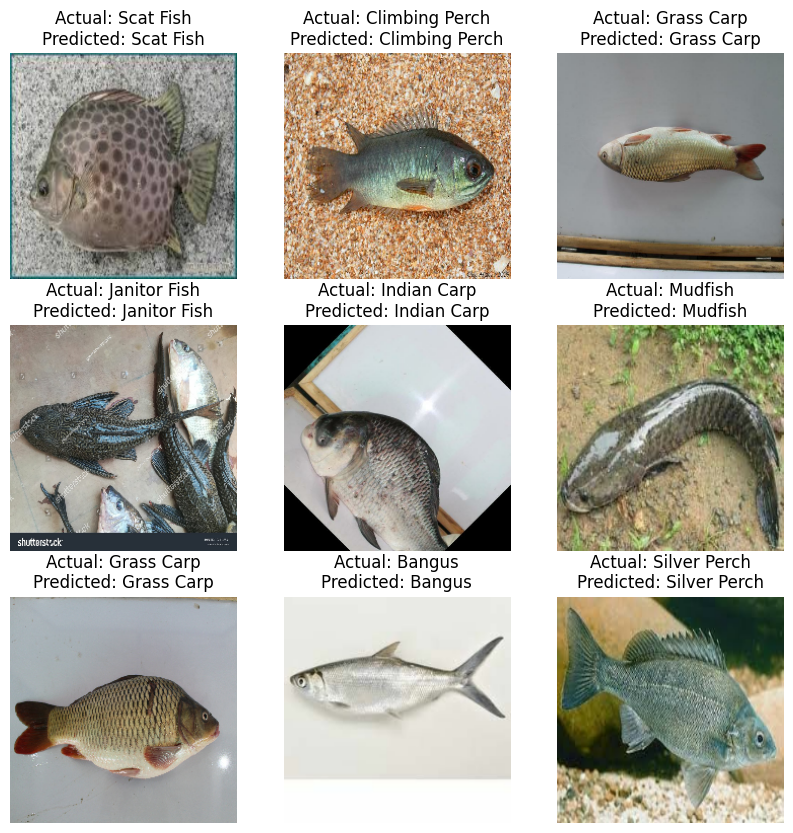

In [ ]:
import numpy as np

for images, labels in test_data.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    actual = class_names[labels[i]]
    predicted = class_names[predicted_labels[i]]
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")
plt.show()
